<a href="https://colab.research.google.com/github/2303A51674/AI-Assistant-Coding/blob/main/Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup: Import Libraries and Check for CUDA

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check if CUDA is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Define Transformations

In [ ]:
# Define transformations for the images
transform = transforms.Compose([
    transforms.Resize(256),        # Resize the image to 256x256
    transforms.CenterCrop(224),    # Crop the image to 224x224 (common for pre-trained models)
    transforms.ToTensor(),         # Convert image to PyTorch tensor
    transforms.Normalize(          # Normalize pixel values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Load the Oxford Flowers 102 Dataset

In [ ]:
# Load the Oxford Flowers 102 dataset
# The `split='train'` refers to the training set of the Flowers102 dataset.
# `download=True` will download the dataset if it's not already available.
train_dataset = torchvision.datasets.Flowers102(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

# Create a DataLoader to iterate over the dataset
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")

100%|██████████| 345M/345M [00:13<00:00, 25.8MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.10MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 47.3MB/s]


Number of training samples: 1020
Number of batches in training loader: 32


### Display a Sample Image (Optional)

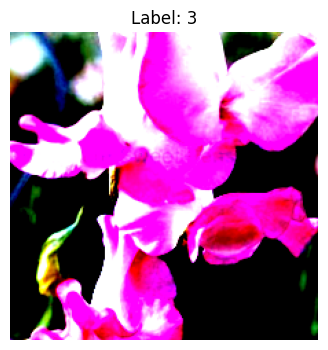

In [ ]:
# Function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Un-normalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display some images
# For visualization, it's better to un-normalize the image if it's normalized.
# However, the transformation applied includes normalization with specific mean/std.
# To correctly display, we need to reverse the normalization.

# Let's get the original image without normalization for display purposes only
# Or, reverse the normalization for the first image in the batch

# This is a simplified way to display without full un-normalization reversal, which might look a bit off
# A more accurate display would require reversing the exact normalize transform.

# For demonstration, let's just display the first image in the batch after converting to numpy
# Note: This display might not be perfectly color-accurate due to normalization reversal approximation.

# To correctly reverse normalization:
# inv_normalize = transforms.Normalize(
#    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
#    std=[1/0.229, 1/0.224, 1/0.225]
# )
# image_to_show = inv_normalize(images[0])

# A simpler display for now:
image_to_show = images[0]
npimg = image_to_show.numpy()
plt.figure(figsize=(4,4))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

### Dataset Overview

In [ ]:
# Get the number of classes
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")

# Display some class names
print("First 10 class names:")
for i, class_name in enumerate(train_dataset.classes[:10]):
    print(f"- {class_name}")

Number of classes: 102
First 10 class names:
- pink primrose
- hard-leaved pocket orchid
- canterbury bells
- sweet pea
- english marigold
- tiger lily
- moon orchid
- bird of paradise
- monkshood
- globe thistle


### Class Distribution

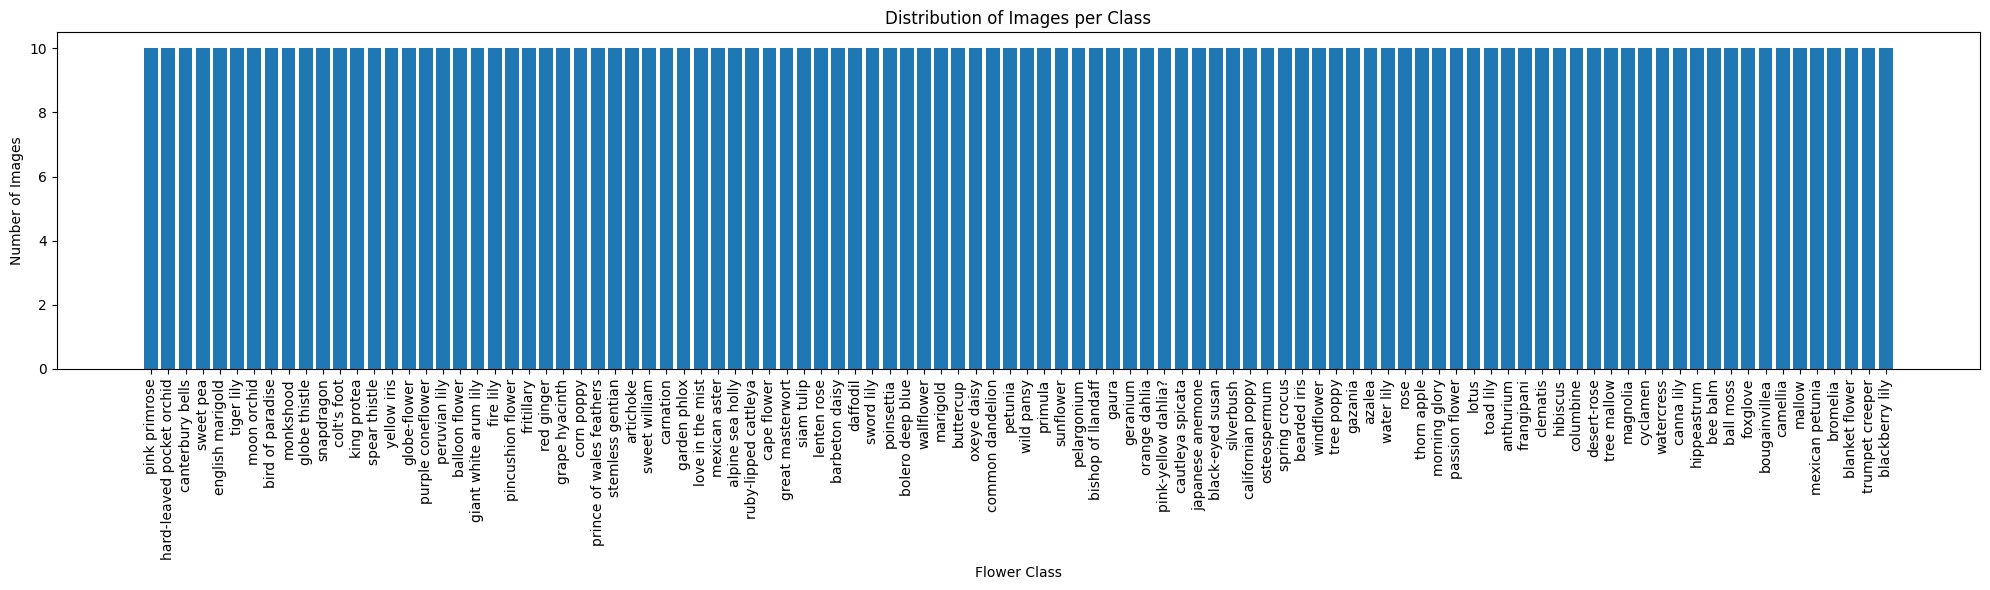

In [ ]:
from collections import Counter

# Get class labels from the dataset
class_labels = [label for _, label in train_dataset]

# Count the occurrences of each class
class_counts = Counter(class_labels)

# Sort the classes by their label for consistent plotting
sorted_class_counts = dict(sorted(class_counts.items()))

# Get class names for x-axis labels
class_names = [train_dataset.classes[i] for i in sorted_class_counts.keys()]
counts = list(sorted_class_counts.values())

plt.figure(figsize=(20, 6))
plt.bar(class_names, counts)
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Class")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Sample Images from the Dataset

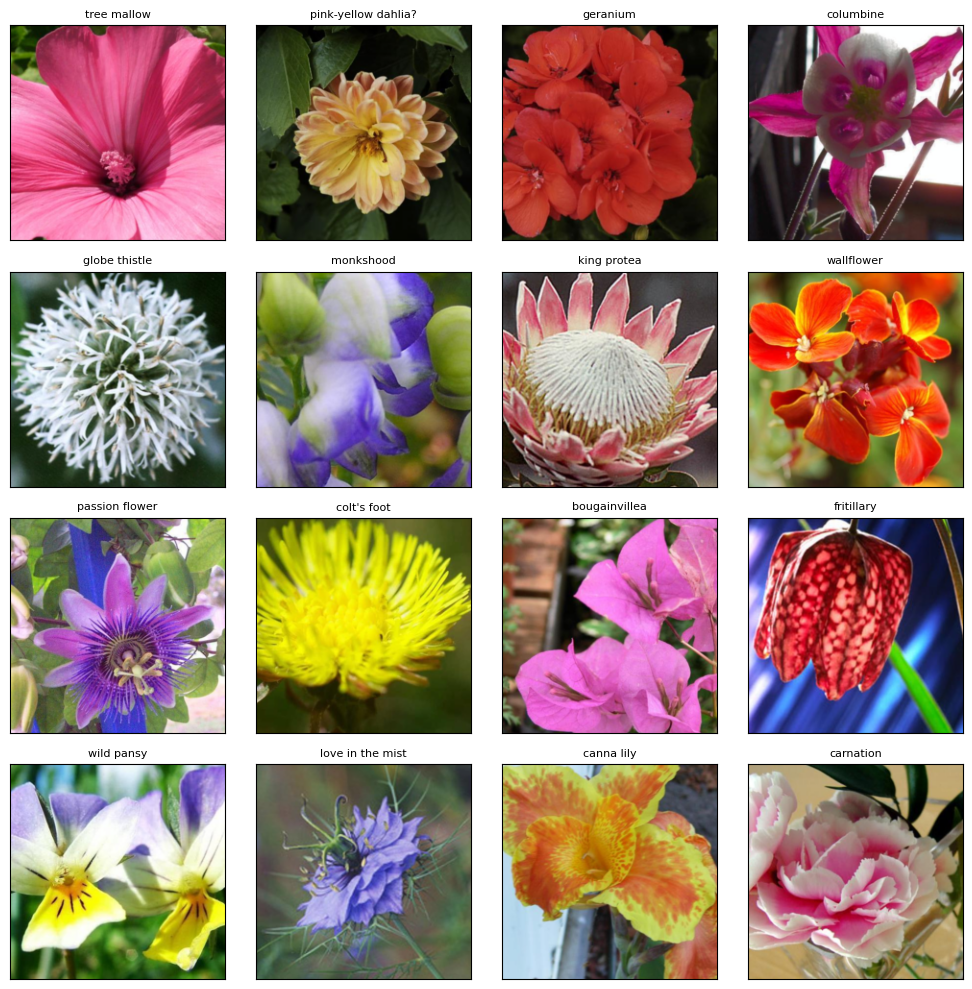

In [ ]:
# Function to un-normalize and display an image (re-defined for clarity if cell is run independently)
def imshow_grid(img):
    # Un-normalize for display if necessary (assuming original transform)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # Un-normalize
    img = np.clip(img, 0, 1)
    return img

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a grid of images
fig = plt.figure(figsize=(10, 10))
rows = 4
cols = 4

for i in range(rows * cols):
    if i < len(images):
        ax = fig.add_subplot(rows, cols, i + 1, xticks=[], yticks=[])
        image_to_show = imshow_grid(images[i].numpy().transpose((1, 2, 0)))
        ax.imshow(image_to_show)
        ax.set_title(train_dataset.classes[labels[i].item()], fontsize=8)
plt.tight_layout()
plt.show()

### Accessing Specific Samples (Rows) and Their Attributes (Columns)

In [ ]:
# Get one batch of images and labels from the training loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Shape of the images tensor (Batch Size, Channels, Height, Width): {images.shape}")
print(f"Shape of the labels tensor (Batch Size): {labels.shape}")

print("\nLabels for the first 5 samples in the batch:")
for i in range(min(5, len(labels))):
    print(f"Sample {i+1}: Label ID = {labels[i].item()}, Class Name = {train_dataset.classes[labels[i].item()]}")

# To display a specific image from this batch, for example the third image:
# You can reuse the imshow_grid function or a similar display method.
# For example:
# plt.figure(figsize=(4,4))
# plt.imshow(imshow_grid(images[2].numpy().transpose((1, 2, 0))))
# plt.title(f"Label: {train_dataset.classes[labels[2].item()]}")
# plt.axis('off')
# plt.show()

Shape of the images tensor (Batch Size, Channels, Height, Width): torch.Size([32, 3, 224, 224])
Shape of the labels tensor (Batch Size): torch.Size([32])

Labels for the first 5 samples in the batch:
Sample 1: Label ID = 81, Class Name = clematis
Sample 2: Label ID = 69, Class Name = tree poppy
Sample 3: Label ID = 41, Class Name = daffodil
Sample 4: Label ID = 76, Class Name = passion flower
Sample 5: Label ID = 67, Class Name = bearded iris


### Calculate Mean and Standard Deviation of the Dataset

In [ ]:
# Define a transform for calculating dataset statistics (excluding normalization)
dataset_stats_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor() # Convert image to PyTorch tensor (values in [0, 1])
])

# Create a new dataset instance with this specific transform
dataset_for_stats = torchvision.datasets.Flowers102(
    root='./data',
    split='train',
    download=False, # Already downloaded
    transform=dataset_stats_transform
)

# Create a DataLoader for this dataset to iterate through
dataset_stats_loader = torch.utils.data.DataLoader(
    dataset_for_stats,
    batch_size=64, # Use a larger batch size for faster calculation if memory allows
    shuffle=False,
    num_workers=2
)

print("Calculating dataset mean and standard deviation...")

mean_sum = torch.zeros(3) # For R, G, B channels
std_sum_sq = torch.zeros(3) # For R, G, B channels (sum of squares)
total_pixels = 0

for images, _ in dataset_stats_loader:
    # Reshape images from (batch_size, channels, H, W) to (batch_size, channels, H*W)
    images_flat = images.view(images.size(0), images.size(1), -1)

    # Sum of pixel values for each channel
    mean_sum += torch.sum(images_flat, dim=[0, 2])

    # Sum of squared pixel values for each channel
    std_sum_sq += torch.sum(images_flat ** 2, dim=[0, 2])

    # Total number of pixels across channels in the batch
    total_pixels += images_flat.size(0) * images_flat.size(2)

# Calculate mean
mean = mean_sum / total_pixels

# Calculate standard deviation using the formula: std = sqrt((sum_sq / N) - mean^2)
std = torch.sqrt((std_sum_sq / total_pixels) - mean ** 2)

print(f"Calculated Mean per channel: {mean}")
print(f"Calculated Standard Deviation per channel: {std}")

Calculating dataset mean and standard deviation...
Calculated Mean per channel: tensor([0.5114, 0.4160, 0.3407])
Calculated Standard Deviation per channel: tensor([0.2956, 0.2492, 0.2888])


### Split Dataset into Training and Validation Sets

In [ ]:
# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split the dataset using random_split
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

print(f"Number of samples in training subset: {len(train_subset)}")
print(f"Number of samples in validation subset: {len(val_subset)}")

# Create DataLoaders for the new training and validation subsets
# Use the same batch_size and num_workers as the original train_loader
train_loader_split = torch.utils.data.DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False, # No need to shuffle validation data
    num_workers=2
)

print(f"Number of batches in new training loader: {len(train_loader_split)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

Number of samples in training subset: 816
Number of samples in validation subset: 204
Number of batches in new training loader: 26
Number of batches in validation loader: 7


### Visualize Sample Images from Each Category

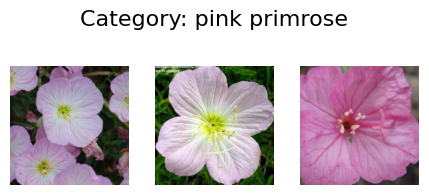

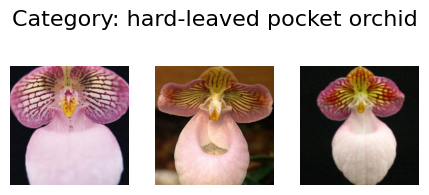

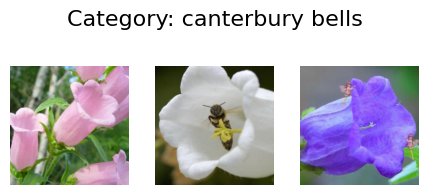

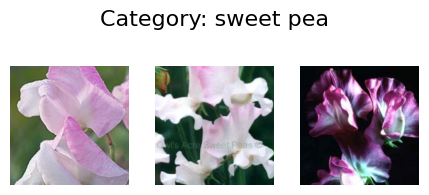

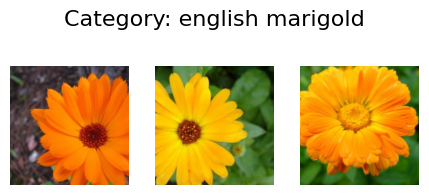

In [ ]:
# Create a dictionary to store images grouped by their class label
images_per_class = {i: [] for i in range(num_classes)}

# Iterate through the entire dataset and store a few images for each class
# Limit the number of images per class to avoid excessive memory usage
max_images_per_class = 3 # Display up to 3 images per class

for i in range(len(train_dataset)):
    image, label = train_dataset[i]
    if len(images_per_class[label]) < max_images_per_class:
        images_per_class[label].append(image)

# Visualize sample images for the first few categories
num_categories_to_show = 5 # Display images from the first 5 categories

# Re-using the imshow_grid function (defined earlier) to un-normalize and display
def imshow_grid(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # Un-normalize
    img = np.clip(img, 0, 1)
    return img

for class_id in range(min(num_categories_to_show, num_classes)):
    class_name = train_dataset.classes[class_id]
    sample_images = images_per_class[class_id]

    if not sample_images:
        print(f"No samples found for class: {class_name}")
        continue

    fig = plt.figure(figsize=(1.5 * max_images_per_class, 2))
    fig.suptitle(f"Category: {class_name}", fontsize=16)

    for i, img_tensor in enumerate(sample_images):
        ax = fig.add_subplot(1, max_images_per_class, i + 1, xticks=[], yticks=[])
        image_to_show = imshow_grid(img_tensor.numpy().transpose((1, 2, 0)))
        ax.imshow(image_to_show)
        ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

### Model Definition and Training

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# Load a pre-trained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # Use default pre-trained weights

# Modify the final fully connected layer to match the number of classes in our dataset
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the appropriate device (GPU if available, else CPU)
model = model.to(device)

print(f"Model loaded and moved to {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Model loaded and moved to cuda


In [ ]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function (CrossEntropyLoss) and optimizer (Adam) defined.")

Loss function (CrossEntropyLoss) and optimizer (Adam) defined.


In [ ]:
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader_split): # Use the split training loader
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader_split)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_accuracy:.2f}%')

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    correct_val = 0
    total_val = 0
    val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs_val, labels_val in val_loader: # Use the validation loader
            inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)
            val_loss += loss_val.item()

            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f'Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_accuracy:.2f}%')

print('Finished Training')

Starting training for 5 epochs...
Epoch [1/5], Training Loss: 0.0216, Training Accuracy: 100.00%
Validation Loss: 0.7798, Validation Accuracy: 78.92%
Epoch [2/5], Training Loss: 0.0092, Training Accuracy: 100.00%
Validation Loss: 0.7389, Validation Accuracy: 78.92%
Epoch [3/5], Training Loss: 0.0056, Training Accuracy: 100.00%
Validation Loss: 0.7096, Validation Accuracy: 81.86%
Epoch [4/5], Training Loss: 0.0038, Training Accuracy: 100.00%
Validation Loss: 0.6674, Validation Accuracy: 81.86%
Epoch [5/5], Training Loss: 0.0039, Training Accuracy: 100.00%
Validation Loss: 0.6658, Validation Accuracy: 80.39%
Finished Training


### Visualize Training and Validation Metrics

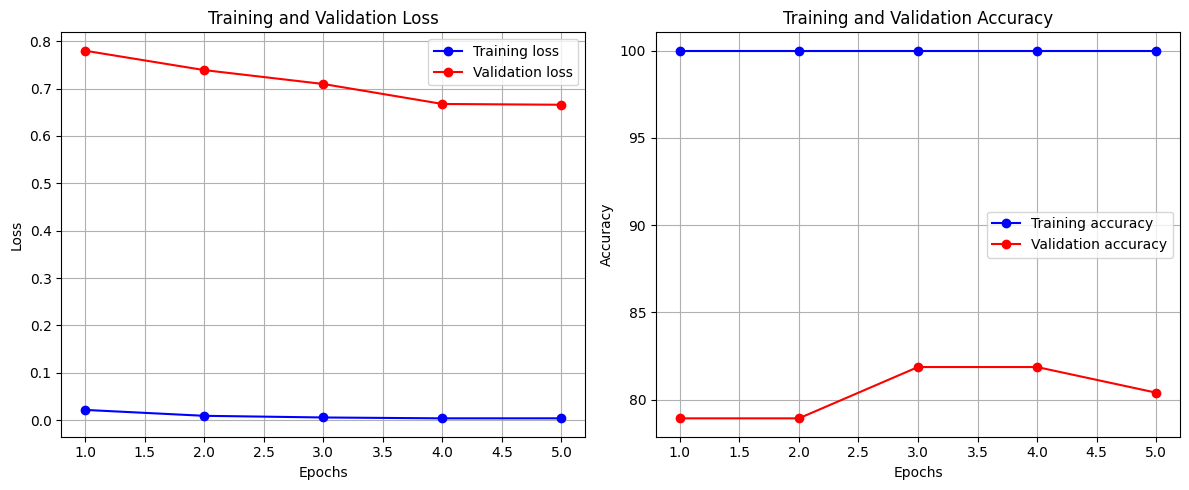

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'bo-', label='Training loss')
plt.plot(epochs, val_losses, 'ro-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'bo-', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'ro-', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluate Model Performance: Confusion Matrix and Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Initialize lists to store true labels and predictions
all_labels = []
all_predictions = []

# Set model to evaluation mode
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Finished collecting predictions from the validation set.")

Finished collecting predictions from the validation set.


In [ ]:
# Generate classification report
# Get the unique labels present in the validation set
unique_labels_in_val = np.unique(all_labels)
# Filter target_names to only include the classes present in the validation set
filtered_target_names = [train_dataset.classes[label] for label in unique_labels_in_val]

report = classification_report(all_labels, all_predictions, labels=unique_labels_in_val, target_names=filtered_target_names, zero_division=0)
print("Classification Report:")
print(report)

Classification Report:
                          precision    recall  f1-score   support

           pink primrose       1.00      1.00      1.00         2
        canterbury bells       0.50      0.25      0.33         4
               sweet pea       0.00      0.00      0.00         1
        english marigold       1.00      1.00      1.00         2
             moon orchid       0.17      1.00      0.29         1
        bird of paradise       1.00      1.00      1.00         1
               monkshood       0.40      1.00      0.57         2
           globe thistle       1.00      1.00      1.00         1
              snapdragon       0.75      0.75      0.75         4
             colt's foot       1.00      1.00      1.00         2
             king protea       1.00      1.00      1.00         2
             yellow iris       1.00      1.00      1.00         3
            globe-flower       1.00      1.00      1.00         2
       purple coneflower       1.00      1.00      1

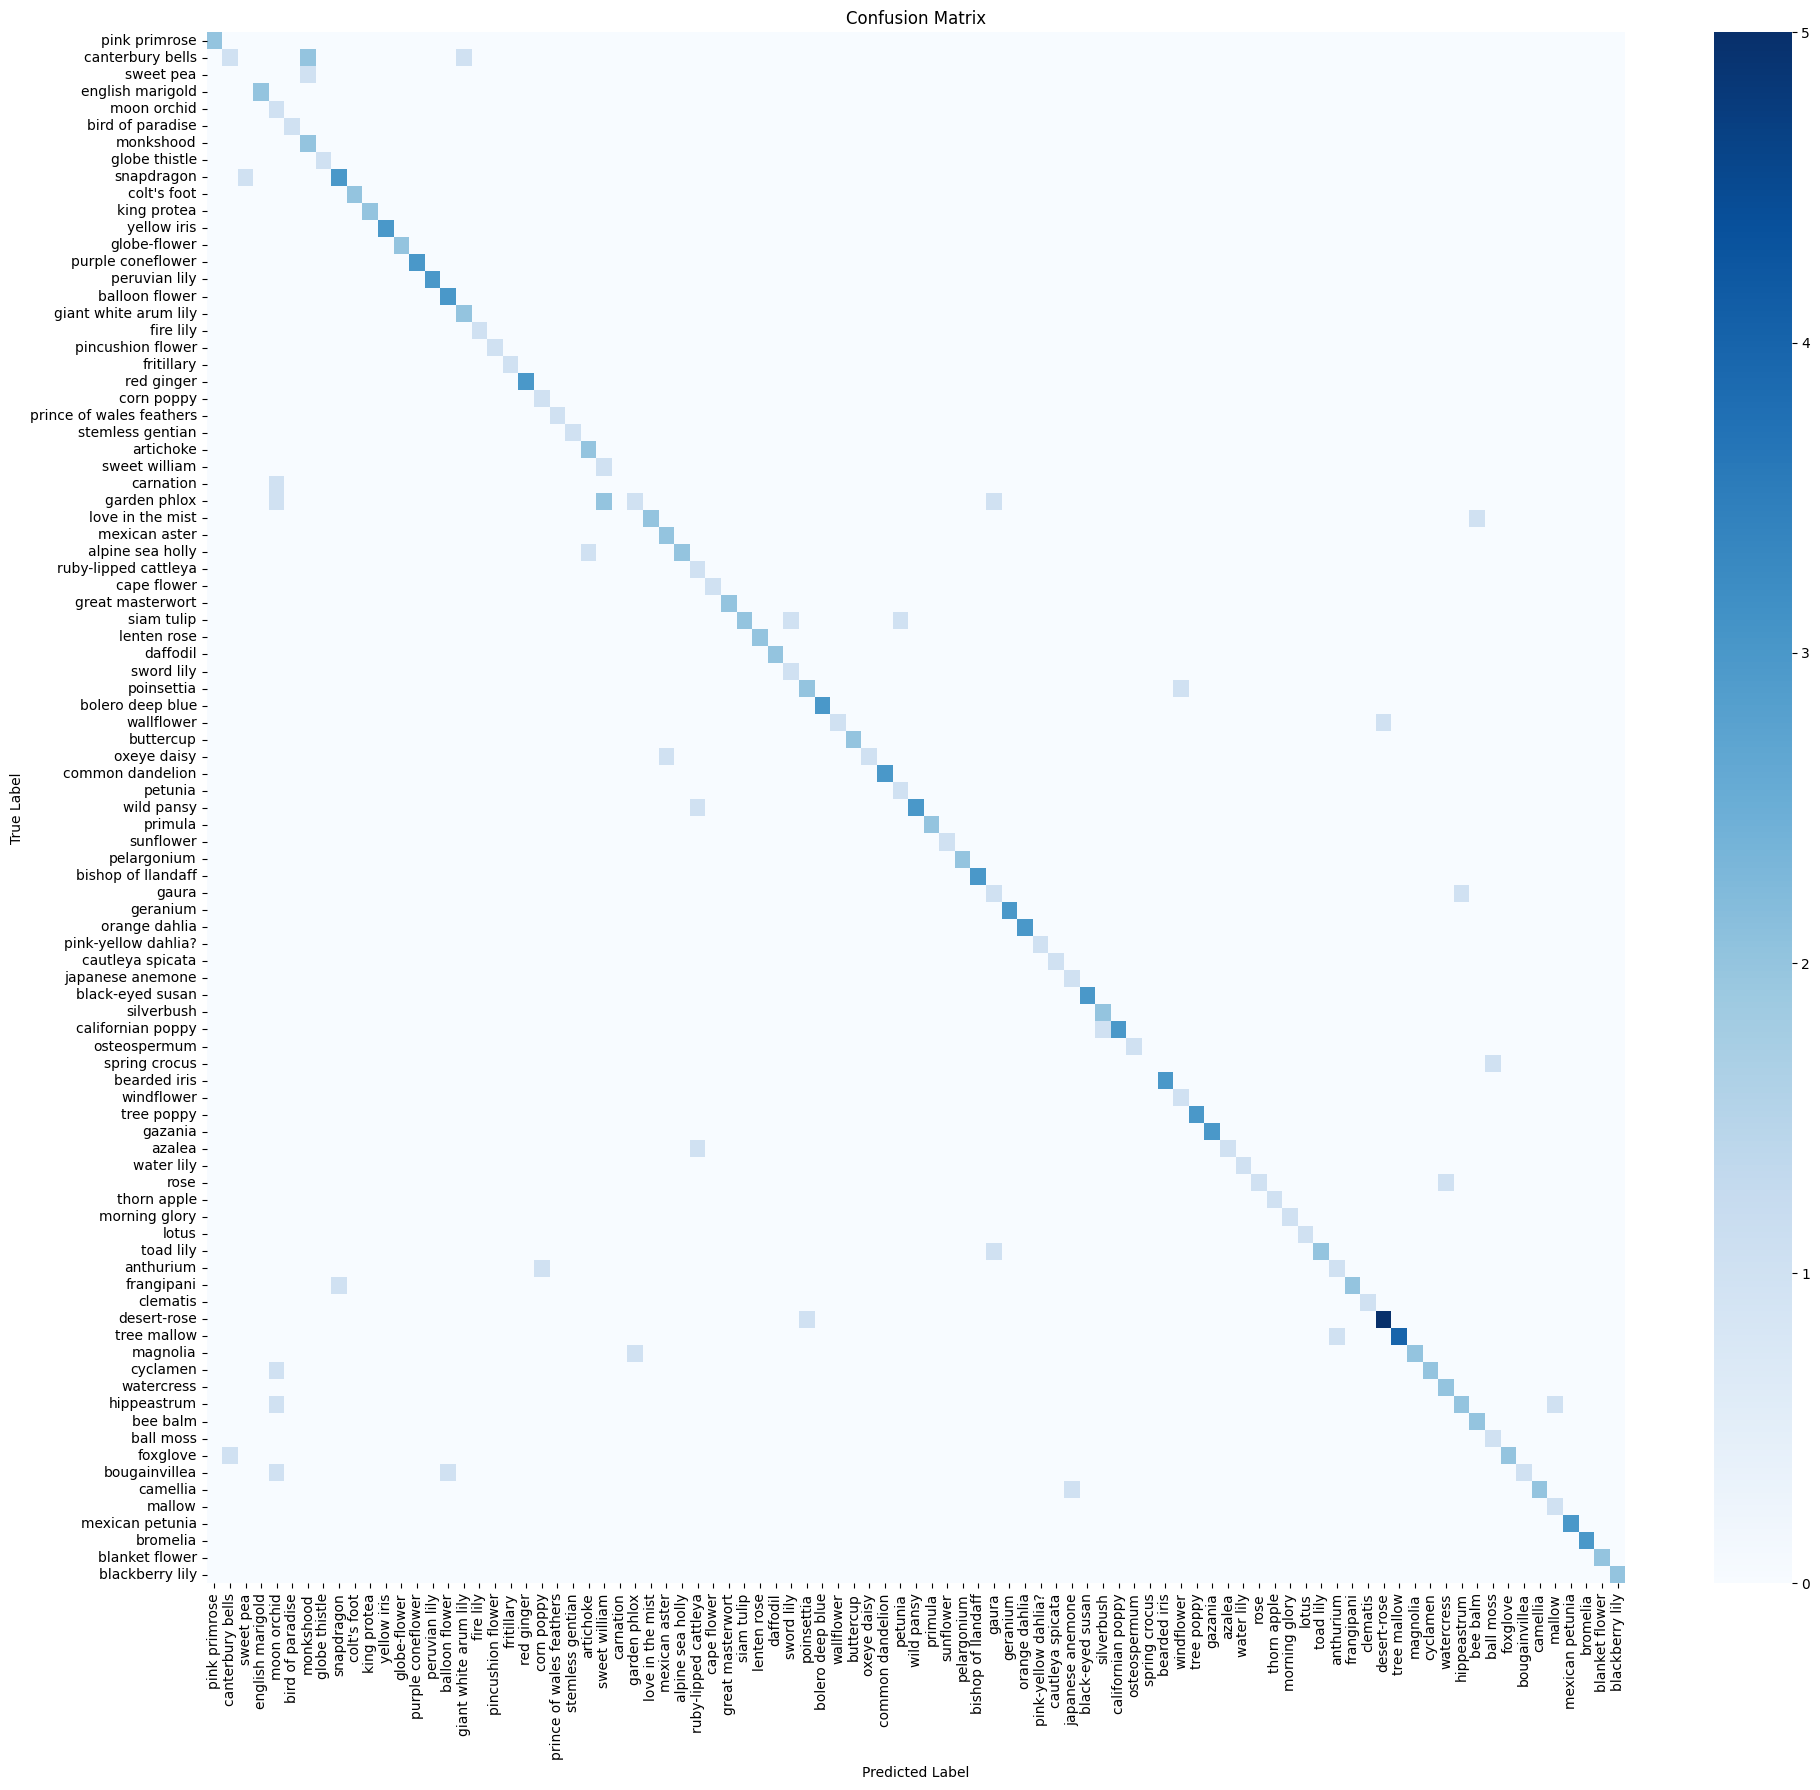

In [ ]:
# Generate confusion matrix
unique_labels_in_val = np.unique(all_labels)
filtered_target_names = [train_dataset.classes[label] for label in unique_labels_in_val]
cm = confusion_matrix(all_labels, all_predictions, labels=unique_labels_in_val)

# Visualize the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=filtered_target_names, yticklabels=filtered_target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
np.set_printoptions(threshold=np.inf) # Display full array without truncation
print("Confusion Matrix (numerical):")
display(cm)
np.set_printoptions(threshold=1000) # Reset print options to default (or preferred)

Confusion Matrix (numerical):


array([[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,